In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import xgboost as xgb
from optuna.integration import XGBoostPruningCallback
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss
)

from imblearn.combine import SMOTETomek
from sklearn.model_selection import StratifiedKFold
from imblearn.combine import SMOTETomek
from sklearn.calibration import calibration_curve
import optuna
import shap
import joblib
shap.initjs()
optuna.logging.set_verbosity(optuna.logging.ERROR)

In [4]:
X_train = joblib.load("data/processed/xgboost/X_train_xgb.pkl")
X_test = joblib.load("data/processed/xgboost/X_test_xgb.pkl")
y_train = joblib.load("data/processed/xgboost/y_train.pkl")
y_test = joblib.load("data/processed/xgboost/y_test.pkl")

In [4]:
print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

print("\nTraining Class Distribution")
print(y_train.value_counts())

print("\nTesting Class Distribution")
print(y_test.value_counts())

Train Shape: (254705, 33)
Test Shape : (84902, 33)

Training Class Distribution
is_fraud
0    253369
1      1336
Name: count, dtype: int64

Testing Class Distribution
is_fraud
0    84456
1      446
Name: count, dtype: int64


In [6]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254705 entries, 0 to 254704
Data columns (total 33 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   amt                       254705 non-null  float64
 1   hour                      254705 non-null  int32  
 2   day                       254705 non-null  int32  
 3   weekday                   254705 non-null  int32  
 4   month                     254705 non-null  int32  
 5   age                       254705 non-null  int64  
 6   distance                  254705 non-null  float64
 7   is_night                  254705 non-null  int32  
 8   hour_sin                  254705 non-null  float64
 9   hour_cos                  254705 non-null  float64
 10  weekday_sin               254705 non-null  float64
 11  weekday_cos               254705 non-null  float64
 12  is_weekend                254705 non-null  int32  
 13  business_hours            254705 non-null  i

In [12]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    print("=" * 60)
    print("Testing Report")
    print("=" * 60)
    print(classification_report(y_test, test_pred, digits=4))

    print("=" * 60)
    print("ROC-AUC")
    print("=" * 60)
    print(f"Train : {roc_auc_score(y_train, train_prob):.6f}")
    print(f"Test  : {roc_auc_score(y_test, test_prob):.6f}")

    print("=" * 60)
    print("PR-AUC")
    print("=" * 60)
    print(f"Average Precision : {average_precision_score(y_test, test_prob):.6f}")

## Baseline XGBoost Model


In [5]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

print(f"scale_pos_weight : {scale_pos_weight:.2f}")

scale_pos_weight : 189.65


In [18]:
baseline_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    device="cuda",

    scale_pos_weight=scale_pos_weight,

    random_state=42,
    n_jobs=-1
)
evaluate_model(baseline_model, X_train, X_test, y_train, y_test)

Testing Report
              precision    recall  f1-score   support

           0     0.9995    0.9987    0.9991     84456
           1     0.7795    0.9036    0.8370       446

    accuracy                         0.9982     84902
   macro avg     0.8895    0.9511    0.9180     84902
weighted avg     0.9983    0.9982    0.9982     84902

ROC-AUC
Train : 1.000000
Test  : 0.998500
PR-AUC
Average Precision : 0.932249


## Baseline Model Cross Validation

In [19]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

roc_scores = []
pr_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr = X_train.iloc[train_idx].copy()
    X_val = X_train.iloc[valid_idx].copy()

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[valid_idx]

    baseline_model.fit( X_tr, y_tr)

    val_prob = baseline_model.predict_proba(X_val)[:, 1]

    roc = roc_auc_score(y_val, val_prob)
    pr = average_precision_score(y_val, val_prob)

    roc_scores.append(roc)
    pr_scores.append(pr)

    print(f"Fold {fold} | "f"ROC-AUC: {roc:.6f} | "f"PR-AUC: {pr:.6f}")

Fold 1 | ROC-AUC: 0.996505 | PR-AUC: 0.907103
Fold 2 | ROC-AUC: 0.997959 | PR-AUC: 0.955030
Fold 3 | ROC-AUC: 0.998609 | PR-AUC: 0.929720
Fold 4 | ROC-AUC: 0.997736 | PR-AUC: 0.936917
Fold 5 | ROC-AUC: 0.997981 | PR-AUC: 0.936252


## Optuna Training strategy 

-5-fold Stratified Cross Validation
- SMOTE-Tomek applied **only to the training portion** of each fold to prevent data leakage
- PR-AUC used as the optimization metric
- GPU acceleration for faster training
- Early stopping and Optuna pruning to reduce unnecessary computation

The best hyperparameters are selected based on the **mean PR-AUC** across all validation folds.

In [5]:
sampler = optuna.samplers.TPESampler(
    seed=42,
    multivariate=True
)

In [18]:
def objective(trial):
    # Define hyperparameters
    params = {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "tree_method": "hist",
        "device": "cuda",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "gamma": trial.suggest_float("gamma", 0.0, 2.0),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 5, log=True),
        "random_state": 42,
        "n_jobs": -1,
        "early_stopping_rounds": 30  # XGBoost 3.x
    }

    # Stratified CV
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    pr_scores = []

    for train_idx, valid_idx in skf.split(X_train, y_train):
        # Split data
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        # Handle imbalance
        smt = SMOTETomek(random_state=42)
        X_tr_res, y_tr_res = smt.fit_resample(X_tr, y_tr)

        # Train model
        model = XGBClassifier(**params)
        model.fit(
            X_tr_res,
            y_tr_res,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        # Predict probabilities
        pred_prob = model.predict_proba(X_val)[:, 1]

        # Collect PR score
        pr_scores.append(average_precision_score(y_val, pred_prob))

    # Return mean score
    return np.mean(pr_scores)


In [19]:
study = optuna.create_study(
    direction="maximize",
    sampler=sampler
)
study.optimize(
    objective,
    n_trials=30,
    show_progress_bar=True
)

  0%|          | 0/30 [00:00<?, ?it/s]

In [15]:
import xgboost
import optuna

print("XGBoost:", xgboost.__version__)
print("Optuna:", optuna.__version__)

XGBoost: 3.2.0
Optuna: 4.8.0


In [22]:
print("=" * 60)
print("Best PR-AUC")
print("=" * 60)
print(study.best_value)

print()

print("=" * 60)
print("Best Parameters")
print("=" * 60)
params = study.best_params
for key, value in study.best_params.items():
    print(f"{key}: {value}")

Best PR-AUC
0.9138916798265964

Best Parameters
learning_rate: 0.13699018182009665
n_estimators: 324
max_depth: 6
min_child_weight: 5
gamma: 0.18852148719986964
subsample: 0.9339376336979083
colsample_bytree: 0.7995651511300546
reg_alpha: 0.08334550398278198
reg_lambda: 1.2441890566083167


In [9]:
params = joblib.load("models/xgboost/xgboost_optuna_study.pkl")

In [10]:
smt = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smt.fit_resample(
    X_train,
    y_train
)

print("Original Training Shape :", X_train.shape)
print("Resampled Training Shape:", X_train_resampled.shape)

print("\nOriginal Class Distribution")
print(y_train.value_counts())

print("\nResampled Class Distribution")
print(y_train_resampled.value_counts())

Original Training Shape : (254705, 33)
Resampled Training Shape: (506712, 33)

Original Class Distribution
is_fraud
0    253369
1      1336
Name: count, dtype: int64

Resampled Class Distribution
is_fraud
0    253356
1    253356
Name: count, dtype: int64


In [13]:
xgb_optuna = XGBClassifier(
    **params,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=-1,
)
evaluate_model(xgb_optuna, X_train_resampled, X_test, y_train_resampled, y_test)

Testing Report
              precision    recall  f1-score   support

           0     0.9991    0.9996    0.9994     84456
           1     0.9225    0.8274    0.8723       446

    accuracy                         0.9987     84902
   macro avg     0.9608    0.9135    0.9359     84902
weighted avg     0.9987    0.9987    0.9987     84902

ROC-AUC
Train : 1.000000
Test  : 0.997178
PR-AUC
Average Precision : 0.921656


In [16]:
xgb_with_weights = XGBClassifier(
    **params,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    device="cuda",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
)
evaluate_model(xgb_with_weights, X_train_resampled, X_test, y_train_resampled, y_test)

Testing Report
              precision    recall  f1-score   support

           0     0.9995    0.9986    0.9990     84456
           1     0.7707    0.8969    0.8290       446

    accuracy                         0.9981     84902
   macro avg     0.8851    0.9477    0.9140     84902
weighted avg     0.9983    0.9981    0.9981     84902

ROC-AUC
Train : 1.000000
Test  : 0.996556
PR-AUC
Average Precision : 0.917715


- The **Optuna + SMOTE-Tomek** model achieved higher **Precision (92.25%)**, **F1-score (87.23%)**, **ROC-AUC (0.9972)**, and **PR-AUC (0.9217)**.
- The **scale_pos_weight** model achieved higher **Recall (89.69%)**, identifying more fraudulent transactions but producing more false positives.
- The higher precision of the Optuna model indicates that fraud predictions are more reliable, while the improved F1-score demonstrates a better overall balance between precision and recall.


## Threshold Optimization

In [72]:
def threshold_optimization(model, X_test, y_test):

    y_prob = model.predict_proba(X_test)[:, 1]

    results = []

    thresholds = np.arange(0.10, 1.00, 0.05)

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        results.append({
            "Threshold": round(threshold, 2),
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1,
            "False Positives": fp,
            "False Negatives": fn
        })

    results = pd.DataFrame(results)

    return results

In [39]:
threshold_optuna = threshold_optimization(
    xgb_optuna,
    X_test,
    y_test
)

threshold_balanced = threshold_optimization(
    xgb_with_weights,
    X_test,
    y_test
)

In [36]:
display(threshold_optuna)

,Threshold,Precision,Recall,F1-Score,False Positives,False Negatives
0,0.10,0.739777,0.892377,0.808943,140,48
1,0.15,0.783730,0.885650,0.831579,109,51
2,0.20,0.814196,0.874439,0.843243,89,56
3,0.25,0.840263,0.860987,0.850498,73,62
4,0.30,0.861364,0.849776,0.855530,61,67
5,0.35,0.883886,0.836323,0.859447,49,73
6,0.40,0.896635,0.836323,0.865429,43,73
7,0.45,0.915842,0.829596,0.870588,34,76
8,0.50,0.922500,0.827354,0.872340,31,77
9,0.55,0.926582,0.820628,0.870392,29,80


In [40]:
display(threshold_balanced)

,Threshold,Precision,Recall,F1-Score,False Positives,False Negatives
0,0.10,0.491667,0.926009,0.642302,427,33
1,0.15,0.559508,0.917040,0.694987,322,37
2,0.20,0.601481,0.910314,0.724353,269,40
3,0.25,0.632238,0.905830,0.744700,235,42
4,0.30,0.661184,0.901345,0.762808,206,44
5,0.35,0.695502,0.901345,0.785156,176,44
6,0.40,0.732601,0.896861,0.806452,146,46
7,0.45,0.750469,0.896861,0.817160,133,46
8,0.50,0.770713,0.896861,0.829016,119,46
9,0.55,0.783890,0.894619,0.835602,110,47


In [41]:
print("Best Threshold - Optuna")
display(threshold_optuna.loc[threshold_optuna["F1-Score"].idxmax()])
print()
print("Best Threshold - Balanced")
display(threshold_balanced.loc[threshold_balanced["F1-Score"].idxmax()])

Best Threshold - Optuna


Threshold           0.500000
Precision           0.922500
Recall              0.827354
F1-Score            0.872340
False Positives    31.000000
False Negatives    77.000000
Name: 8, dtype: float64


Best Threshold - Balanced


Threshold           0.900000
Precision           0.879630
Recall              0.852018
F1-Score            0.865604
False Positives    52.000000
False Negatives    66.000000
Name: 16, dtype: float64

**Optuna + SMOTE-Tomek**

- The optimal threshold was **0.50**, achieving the highest **F1-score of 87.23%**.
- At this threshold, the model achieved **92.25% precision** and **82.74% recall**, while producing only **31 false positives**.
- This operating point provides reliable fraud predictions with minimal unnecessary customer interventions.

**scale_pos_weight**

- The optimal threshold was **0.90**, resulting in an **F1-score of 86.56%**.
- Although this model achieved a slightly higher **recall (85.20%)**, it generated **52 false positives**, making it less precise than the Optuna model.

Overall, the **Optuna + SMOTE-Tomek** model was selected because it achieved the highest F1-score, superior precision, fewer false positives, and stronger overall predictive performance while maintaining competitive fraud detection capability.

In [17]:
# Predictions from both models
y_pred_optuna = xgb_optuna.predict(X_test)
y_pred_weights = xgb_with_weights.predict(X_test)

# Probabilities from both models
y_prob_optuna  = xgb_optuna.predict_proba(X_test)[:, 1]
y_prob_weights = xgb_with_weights.predict_proba(X_test)[:, 1]

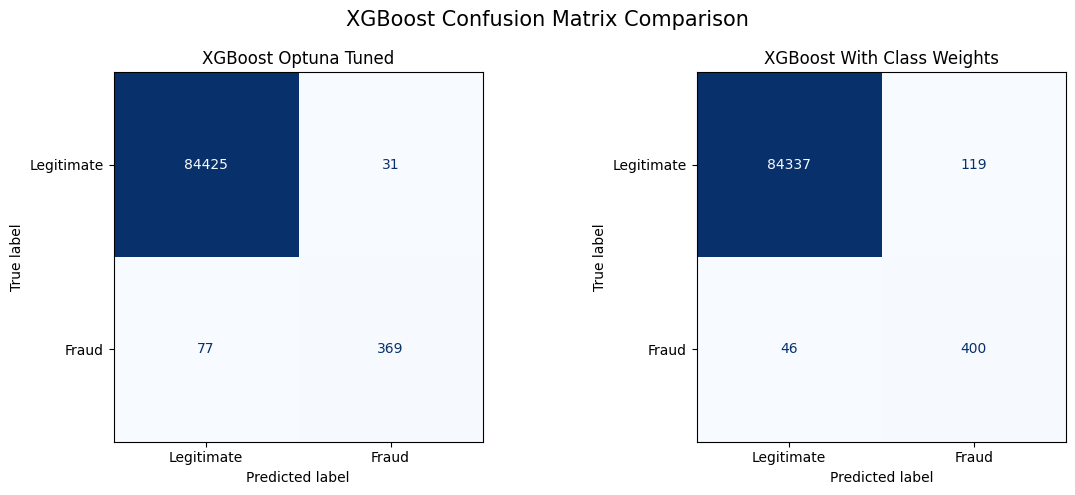

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion matrix for Optuna-tuned model
cm_optuna = confusion_matrix(y_test, y_pred_optuna)
disp_optuna = ConfusionMatrixDisplay(
    confusion_matrix=cm_optuna,
    display_labels=["Legitimate", "Fraud"]
)
disp_optuna.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
axes[0].set_title("XGBoost Optuna Tuned")

# Confusion matrix for Weighted model
cm_weights = confusion_matrix(y_test, y_pred_weights)
disp_weights = ConfusionMatrixDisplay(
    confusion_matrix=cm_weights,
    display_labels=["Legitimate", "Fraud"]
)
disp_weights.plot(ax=axes[1], cmap="Blues", values_format="d", colorbar=False)
axes[1].set_title("XGBoost With Class Weights")

plt.suptitle("XGBoost Confusion Matrix Comparison", fontsize=15)
plt.tight_layout()
plt.show()

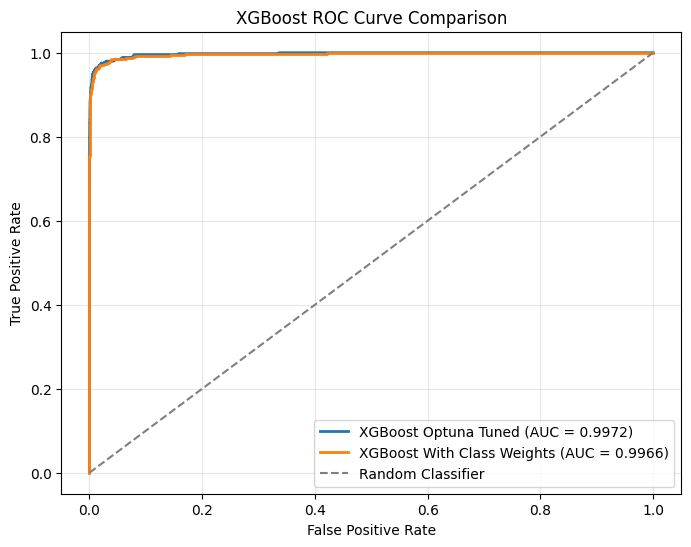

In [21]:
# ROC curve values
fpr_optuna, tpr_optuna, _   = roc_curve(y_test, y_prob_optuna)
fpr_weights, tpr_weights, _ = roc_curve(y_test, y_prob_weights)

# AUC scores
auc_optuna  = roc_auc_score(y_test, y_prob_optuna)
auc_weights = roc_auc_score(y_test, y_prob_weights)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(fpr_optuna, tpr_optuna, linewidth=2,
         label=f"XGBoost Optuna Tuned (AUC = {auc_optuna:.4f})")

plt.plot(fpr_weights, tpr_weights, linewidth=2,
         label=f"XGBoost With Class Weights (AUC = {auc_weights:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


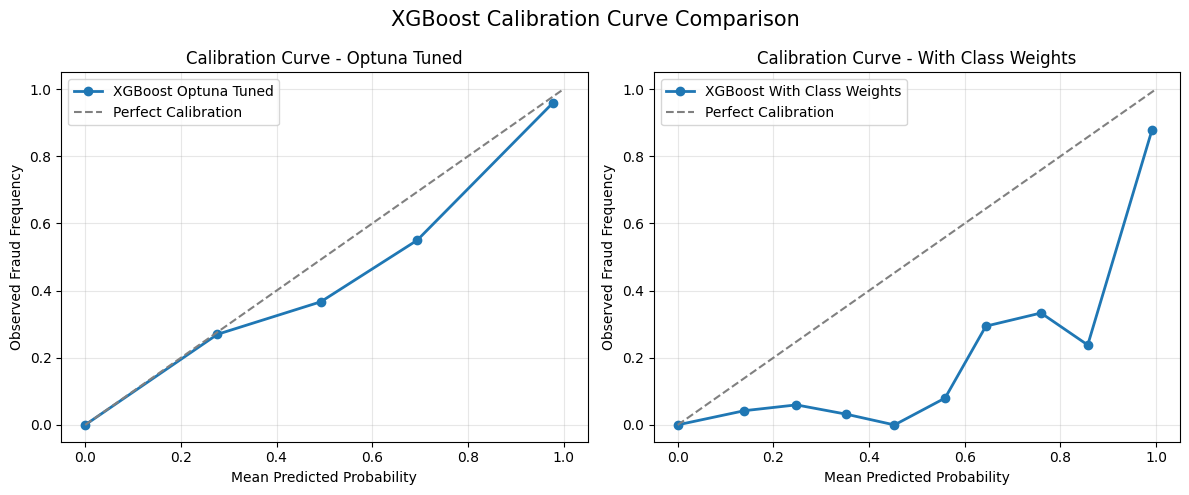

In [43]:
# Calibration curve 
prob_true_optuna, prob_pred_optuna = calibration_curve(
    y_test,
    y_prob_optuna,   
    strategy="uniform"
)

prob_true_weights, prob_pred_weights = calibration_curve(
    y_test,
    y_prob_weights,  
    n_bins=10,
    strategy="uniform"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Optuna-tuned model calibration curve
axes[0].plot(prob_pred_optuna, prob_true_optuna, marker="o", linewidth=2,
             label="XGBoost Optuna Tuned")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")
axes[0].set_title("Calibration Curve - Optuna Tuned")
axes[0].set_xlabel("Mean Predicted Probability")
axes[0].set_ylabel("Observed Fraud Frequency")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Weighted model calibration curve
axes[1].plot(prob_pred_weights, prob_true_weights, marker="o", linewidth=2,
             label="XGBoost With Class Weights")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration")
axes[1].set_title("Calibration Curve - With Class Weights")
axes[1].set_xlabel("Mean Predicted Probability")
axes[1].set_ylabel("Observed Fraud Frequency")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("XGBoost Calibration Curve Comparison", fontsize=15)
plt.tight_layout()
plt.show()


- The **Optuna + SMOTE-Tomek** model follows the perfect calibration line more closely, indicating more reliable probability estimates.
- The **class-weighted** model shows larger deviations from the ideal line, especially at medium probability levels.
- Better calibration makes probability scores more reliable for threshold selection and fraud detection.

## SHAP Analysis

In [22]:
explainer = shap.Explainer(xgb_optuna)

shap_values = explainer(X_test)

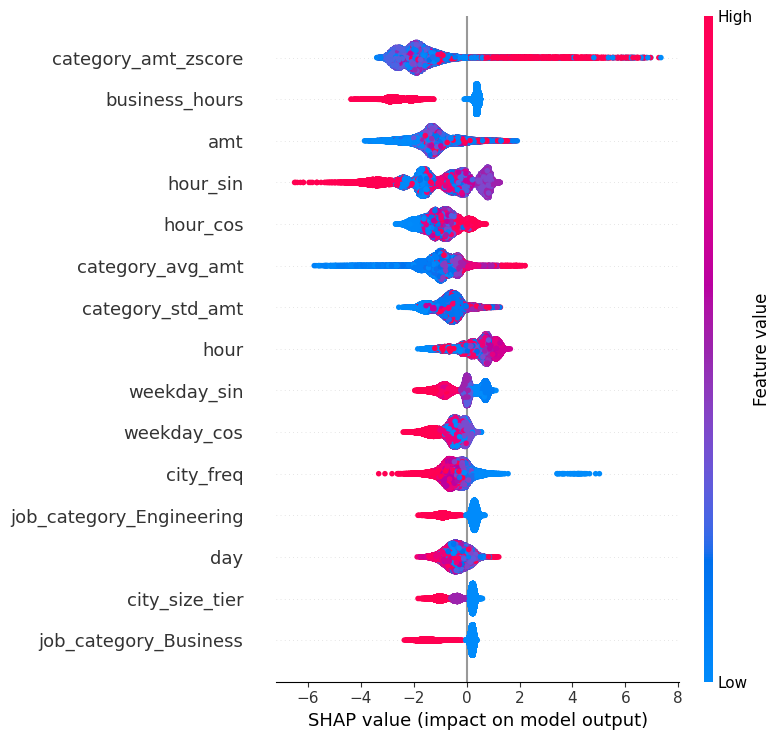

In [23]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=15
)



- **`category_amt_zscore`** is the most important feature, showing that abnormal spending behavior is the strongest indicator of fraud.
- **`business_hours`** and time-related features (`hour`, `hour_sin`, `hour_cos`) indicate that transaction timing plays a major role in fraud detection.
- **`amt`**, **`category_avg_amt`**, and **`category_std_amt`** help identify unusual transaction amounts.
- Features such as **`city_freq`** and job categories provide additional information but have a smaller impact.

### SHAP Waterfall Plot 

In [25]:
fraud_index = y_test[y_test == 1].index[0]

position = X_test.index.get_loc(fraud_index)

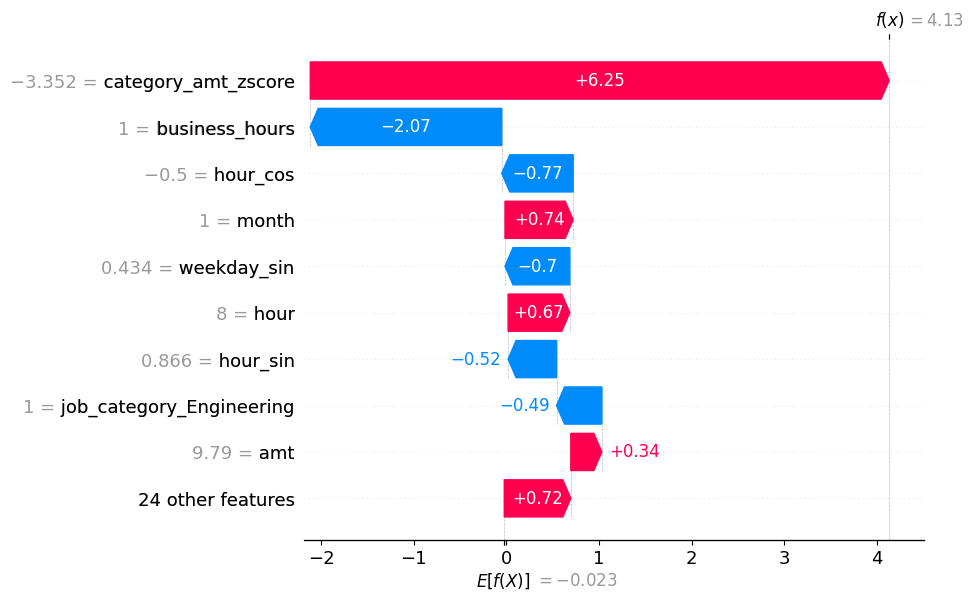

In [26]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[position],
        base_values=explainer.expected_value,
        data=X_test.iloc[position],
        feature_names=X_test.columns
    )
)

- **`category_amt_zscore`** is the biggest contributor, significantly increasing the fraud prediction.
- Features such as **`month`**, **`hour`**, and **`amt`** also increase the fraud score.
- **`business_hours`**, **`hour_cos`**, and **`weekday_sin`** reduce the fraud probability for this transaction.


## Feature Importance

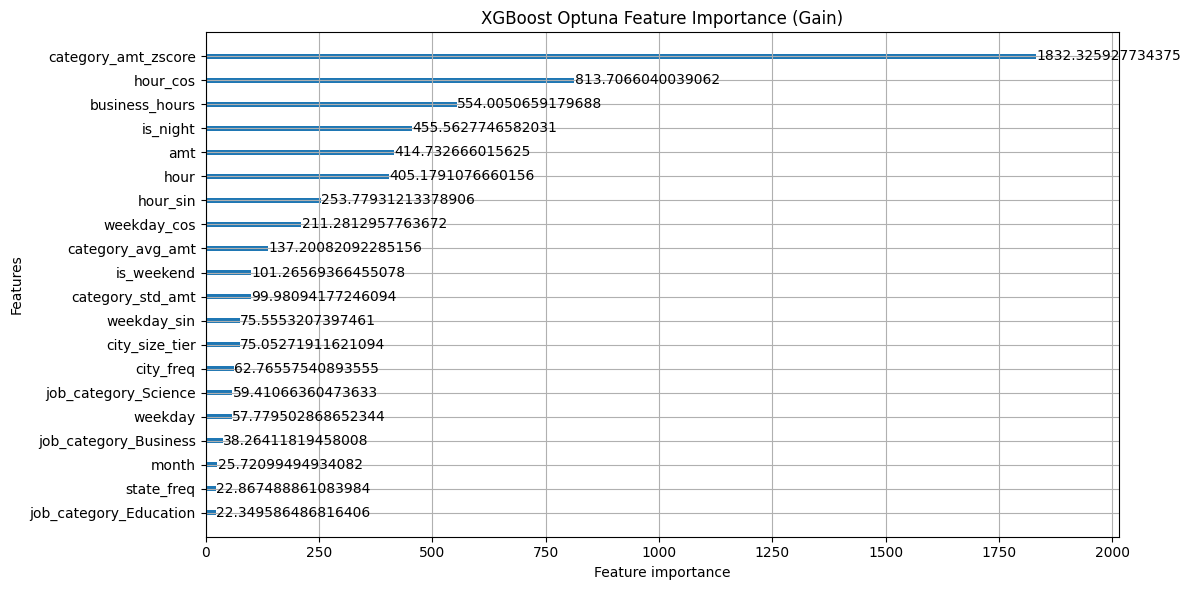

In [41]:
# Gain‑based feature importance
fig, ax = plt.subplots(figsize=(12, 6))  
xgb.plot_importance(
    xgb_optuna,
    importance_type="gain",
    max_num_features=20,
    ax=ax  
)
ax.set_title("XGBoost Optuna Feature Importance (Gain)")
ax.set_xlabel("Feature importance")
ax.set_ylabel("Features")
plt.tight_layout()
plt.show()


### Save Model


In [ ]:
joblib.dump(xgb_optuna, "artifacts/xgboost/xgb_model.pkl")